### PH464/564: Scientific Computing II
***J.S. Hazboun***

___

# Homework 4
### Due: Monday, Oct 27th at 11:59pm Pacific
---

# Week 4     HW

The purpose of this assignment is to use the Metropolis algorithm to infer model parameters by sampling a _posterior distribution_.  Let's return to our linear regression problem.

Using the synthetic $x-y$ data set from [Hogg, Bovy, and Lang (2010)](https://arxiv.org/abs/1008.4686) (in the `data` directory of this repo), assume a **uniform prior** over slope and y-intercept and use the Metropolis algorithm to draw samples from the posterior density function describing our knowledge of the slope and y-intercept given the observed data.

To do this you will have to extend our 1-D Markov chains from class to 2-D, meaning we have a 2-D parameter space to explore and you will have to decide a method (or methods) to propose moves in those two dimensions.

Show the quality of the fit to the data and the associated uncertainty by plotting the lines corresponding to several samples from your chain on top of the data

Make one or several figures showing your estimate of the 2-D posterior distribution.  Are there correlations between the model parameters?

### Solution



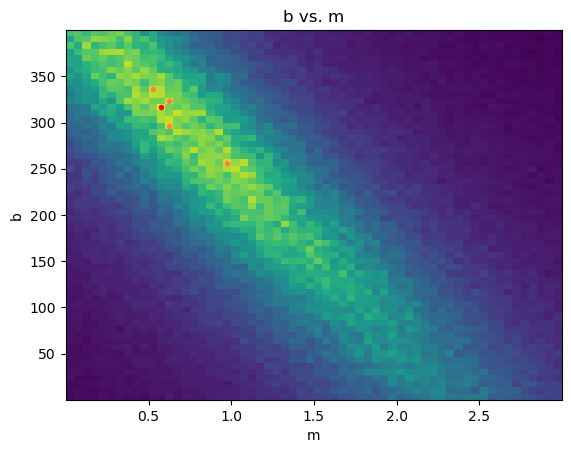

The best fit line is approximately: 0.575 * x + 316.682
The second best fit line is approximately: 0.625 * x + 296.681
The third best fit line is approximately: 0.625 * x + 323.349
The fourth best fit line is approximately: 0.975 * x + 256.679
The fifth best fit line is approximately: 0.525 * x + 336.683


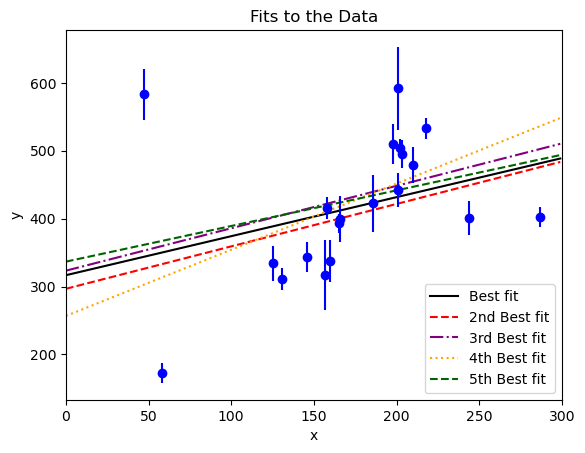

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define uniform prior
def build_model(m, b):
    def model(x):
        return m * x + b
    return model

# Define a function to get index from 2D matrix
def index_2d(array, v):
    for w, x in enumerate(array):
        if v in x:
            return (w, x.index(v))

# Read the file
df = pd.read_csv("Data/data_yerr.dat", delimiter='&')

# Sort the data into appropriate lists
x = df[' x '].tolist()
y = df[' y '].tolist()
sigmay = df[' sigm_y'].tolist()

# Define lists for the Metropolis Algorithm
mguess = []
bguess = []
errorguess = []

# Define variables for the Metropolis Algorithm
b0 = 0
b = b0
m0 = 0
m = m0
error_current = 100000000
niter = 1250000

# Start of algorithm
for i in range(niter):
    # Pick new point and reset error
    m0 = np.random.uniform(0,3)
    b0 = np.random.uniform(0,400)
    model = build_model(m0, b0)
    error = 0
    
    # Calculate least squares error of this fit
    for j in range(len(x)):
        error += (y[j] - model(x[j]))**2
        
    # Decide acceptance
    alpha = error_current/error
    u = np.random.uniform()
    accepted = u < alpha
    
    # Move to new location
    if accepted:
        m = m0
        b = b0
        error_current = error
        
    # Update lists
    mguess.append(m)
    bguess.append(b)
    errorguess.append(error_current)

# Set the burn-in
burnin = int(niter/5)

# Find where the bin with the max height is located
counts, x_ind, y_ind = np.histogram2d(mguess[burnin:], bguess[burnin:], bins=60)
x_most, y_most = np.unravel_index(np.argmax(counts), counts.shape)

# Get the values of the 2nd-5th largest bins
counts2 = np.partition(counts.flatten(), -2)[-2]
counts3 = np.partition(counts.flatten(), -3)[-3]
counts4 = np.partition(counts.flatten(), -4)[-4]
counts5 = np.partition(counts.flatten(), -5)[-5]

# Find indices of the 2nd-5th largest bins
countslist = counts.tolist()
x_most2, y_most2 = index_2d(countslist, counts2)
x_most3, y_most3 = index_2d(countslist, counts3)
x_most4, y_most4 = index_2d(countslist, counts4)
x_most5, y_most5 = index_2d(countslist, counts5)

# Converting from the indices to the m and b values
m1st = x_most/20+0.025
b1st = y_most*6.667+3.333
m2nd = x_most2/20+0.025
b2nd = y_most2*6.667+3.333
m3rd = x_most3/20+0.025
b3rd = y_most3*6.667+3.333
m4th = x_most4/20+0.025
b4th = y_most4*6.667+3.333
m5th = x_most5/20+0.025
b5th = y_most5*6.667+3.333

# Plot the histogram with the largest bin marked in red
# Next largest bins marked in softer color
plt.hist2d(mguess[burnin:], bguess[burnin:], bins=60)
plt.scatter(m1st, b1st, marker='.', color='r')
plt.scatter(m2nd, b2nd, marker='.', color='coral')
plt.scatter(m3rd, b3rd, marker='.', color='coral')
plt.scatter(m4th, b4th, marker='.', color='coral')
plt.scatter(m5th, b5th, marker='.', color='coral')
plt.xlabel('m')
plt.ylabel('b')
plt.title('b vs. m')
plt.show()

# Define the best-fit lines
model = build_model(m1st, b1st)
print("The best fit line is approximately:", f"{m1st:.3f}", "* x +", f"{b1st:.3f}")
model2 = build_model(m2nd, b2nd)
print("The second best fit line is approximately:", f"{m2nd:.3f}", "* x +", f"{b2nd:.3f}")
model3 = build_model(m3rd, b3rd)
print("The third best fit line is approximately:", f"{m3rd:.3f}", "* x +", f"{b3rd:.3f}")
model4 = build_model(m4th, b4th)
print("The fourth best fit line is approximately:", f"{m4th:.3f}", "* x +", f"{b4th:.3f}")
model5 = build_model(m5th, b5th)
print("The fifth best fit line is approximately:", f"{m5th:.3f}", "* x +", f"{b5th:.3f}")

# Plot the fits to the data
xsamps = np.arange(0, 300)
plt.plot(xsamps, model(xsamps), label='Best fit', color='k')
plt.plot(xsamps, model2(xsamps), label='2nd Best fit', linestyle='--', color='r')
plt.plot(xsamps, model3(xsamps), label='3rd Best fit', linestyle='-.', color='purple')
plt.plot(xsamps, model4(xsamps), label='4th Best fit', linestyle=':', color='orange')
plt.plot(xsamps, model5(xsamps), label='5th Best fit', linestyle='--', color='darkgreen')
plt.xlim(0, 300)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fits to the Data')
plt.legend()
plt.errorbar(x, y, yerr=sigmay, linestyle='None', color='b', marker='o');
plt.show()